In [1]:
# CELL 1: Load Data + Encoding + Scaling + Train/Test Split

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ML Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

print("Loading processed dataset...")
df = pd.read_csv("../data/processed_diamonds.csv")

print("Columns:", df.columns.tolist())

TARGET = "price_inr"

NUM_FEATURES = [col for col in ['carat','depth','table','y','z','volume'] if col in df.columns]
CAT_FEATURES = ["cut", "color", "clarity"]

X = df[NUM_FEATURES + CAT_FEATURES]
y = df[TARGET]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- Ordinal Encoding ----------
cut_order = ['Fair','Good','Very Good','Premium','Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
X_train_cat = encoder.fit_transform(X_train_raw[CAT_FEATURES])
X_test_cat = encoder.transform(X_test_raw[CAT_FEATURES])

joblib.dump(encoder, "../models/encoder.pkl")

# ---------- Scaling ----------
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_raw[NUM_FEATURES])
X_test_num = scaler.transform(X_test_raw[NUM_FEATURES])

joblib.dump(scaler, "../models/scaler.pkl")

# Combined arrays
X_train = np.hstack([X_train_num, X_train_cat])
X_test = np.hstack([X_test_num, X_test_cat])

print("Encoded + Scaled Feature Shape:", X_train.shape)


Loading processed dataset...
Columns: ['cut', 'color', 'clarity', 'depth', 'table', 'y', 'z', 'price_per_carat', 'dimension_ratio', 'Carat_Category', 'carat', 'price_inr', 'volume']
Encoded + Scaled Feature Shape: (37224, 9)


In [2]:
# CELL 2: Train 5 ML Models

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=350,
        learning_rate=0.08,
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae, rmse, r2 = evaluate(y_test, pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}
    print(f"{name} → RMSE: {rmse:.4f}, R²: {r2:.4f}")

results_df = pd.DataFrame(results).T.sort_values("RMSE")
print("\nModel Performance:")
print(results_df.round(4))



Training Linear Regression...
Linear Regression → RMSE: 0.1404, R²: 0.9761

Training Random Forest...
Random Forest → RMSE: 0.0919, R²: 0.9897

Training Decision Tree...
Decision Tree → RMSE: 0.1260, R²: 0.9807

Training KNN...
KNN → RMSE: 0.1317, R²: 0.9789

Training XGBoost...
XGBoost → RMSE: 0.0842, R²: 0.9914

Model Performance:
                      MAE    RMSE      R²
XGBoost            0.0617  0.0842  0.9914
Random Forest      0.0679  0.0919  0.9897
Decision Tree      0.0875  0.1260  0.9807
KNN                0.0997  0.1317  0.9789
Linear Regression  0.1088  0.1404  0.9761


291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

ANN → RMSE: 0.1127, R²: 0.9846

Final Performance Comparison:
                      MAE    RMSE      R²
XGBoost            0.0617  0.0842  0.9914
Random Forest      0.0679  0.0919  0.9897
ANN                0.0881  0.1127  0.9846
Decision Tree      0.0875  0.1260  0.9807
KNN                0.0997  0.1317  0.9789
Linear Regression  0.1088  0.1404  0.9761


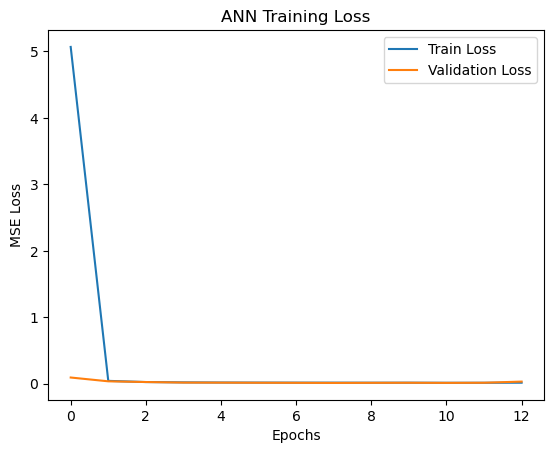

In [3]:
# CELL 3: ANN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def build_ann(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

ann = build_ann(X_train.shape[1])

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = ann.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=0
)

ann_pred = ann.predict(X_test).flatten()
ann_mae, ann_rmse, ann_r2 = evaluate(y_test, ann_pred)

print(f"\nANN → RMSE: {ann_rmse:.4f}, R²: {ann_r2:.4f}")

# Add ANN to results
results["ANN"] = {"MAE": ann_mae, "RMSE": ann_rmse, "R²": ann_r2}

results_df = pd.DataFrame(results).T.sort_values("RMSE")
print("\nFinal Performance Comparison:")
print(results_df.round(4))

# Plot Loss Curve
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ANN Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [4]:
# CELL 4: SAVE BEST MODEL

best_model_name = results_df.index[0]
print("\nBest Model:", best_model_name)

if best_model_name == "ANN":
    ann.save("../models/best_model_ann.h5")
    print("✔ Saved ANN model as best_model_ann.h5")
else:
    best_model = models[best_model_name]
    joblib.dump(best_model, "../models/best_model.pkl")
    print("✔ Saved ML model as best_model.pkl")



Best Model: XGBoost
✔ Saved ML model as best_model.pkl
